In [1]:
import numpy as np
from matplotlib import matplotlib_fname
import matplotlib
import handy.my_utils as deniz
import matplotlib.pyplot as plt
import os
import mne

from EEGPreprocessor import EEGPreprocessor


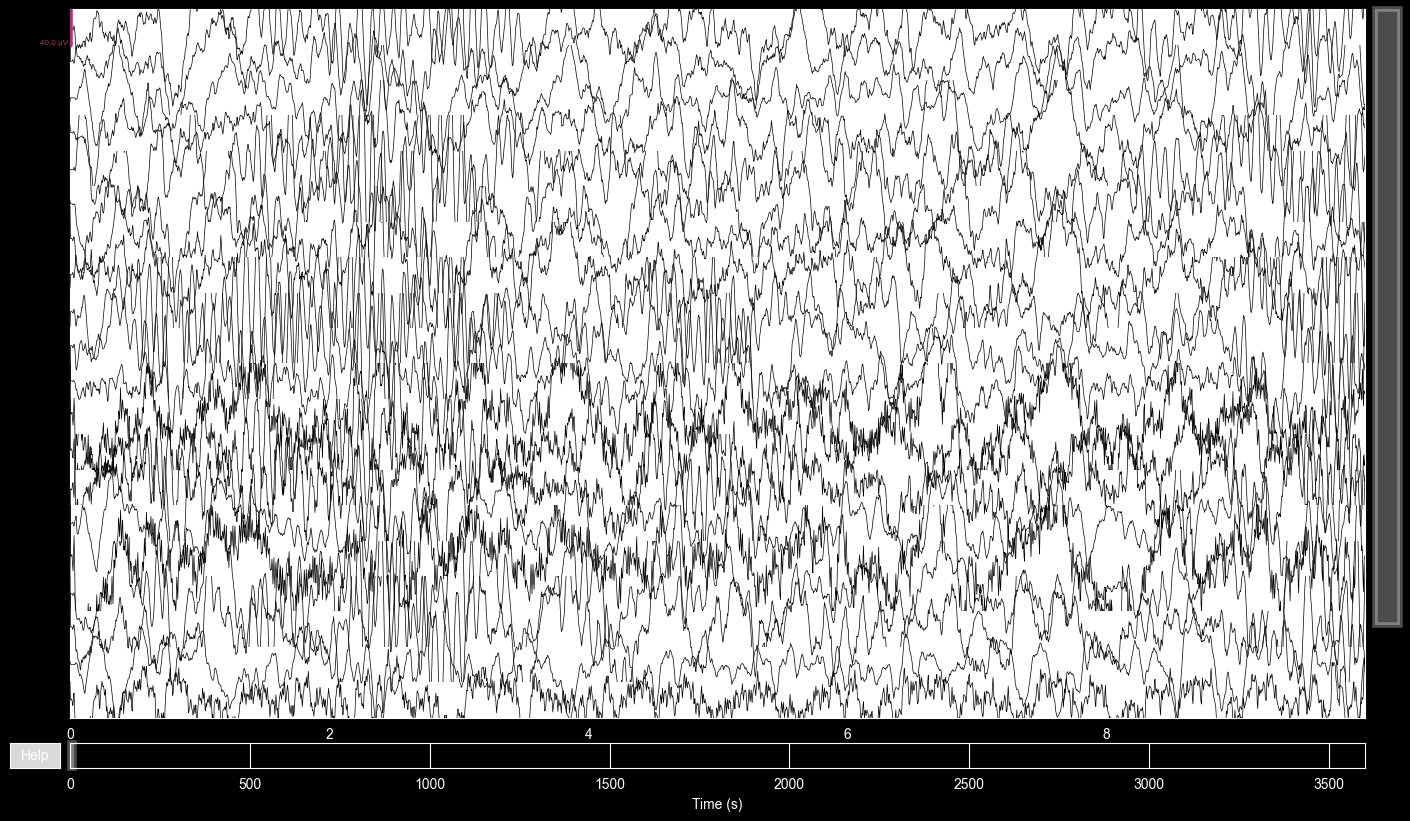

In [2]:
dataset_path = 'data-understanding/data/chb-mit'
# 1. Define the actual string path to the file
file_path = 'data-understanding/data/chb-mit/chb01/chb01_03.edf'

# 2. Load the file using MNE (this expects the string path)
raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

# 3. Visualize
raw.plot()


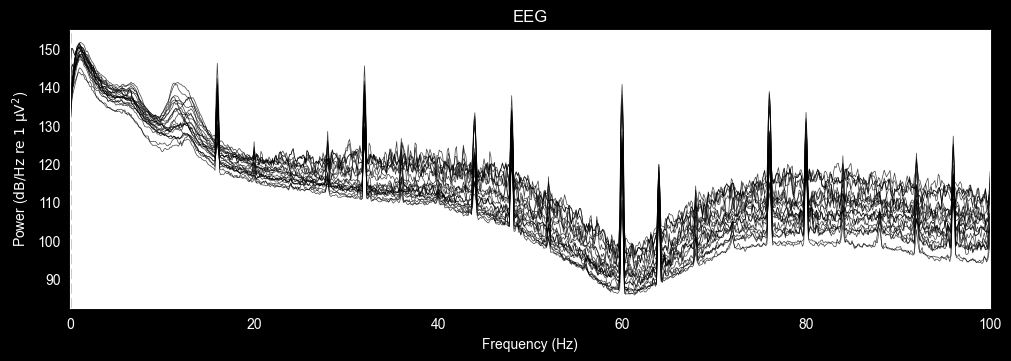

In [3]:
signals, channel_names, fs = deniz.load_edf_file('data-understanding/data/chb-mit/chb01/chb01_03.edf')

# 2. Create MNE Info object
# Note: CHB-MIT data is usually in microvolts; MNE expects Volts.
# If your loader hasn't scaled it, multiply by 1e-6
info = mne.create_info(ch_names=list(channel_names), sfreq=fs, ch_types='eeg')
raw_array = mne.io.RawArray(signals, info)

# 3. Compute PSD
# fmax=100 helps focus on the relevant brain wave frequencies
spectrum = raw_array.compute_psd(fmax=100)

# 4. Visualize
with plt.style.context({'axes.facecolor': 'white', 'axes.grid': False}):
    # Spatial colors help identify which area of the brain has more power
    fig1 = spectrum.plot(
        average=False,
        spatial_colors=True,
        picks="data"
    )
    plt.show()

# After preprocessing

In [4]:
preprocessor = EEGPreprocessor(sampling_rate= 256 ,target_sfreq=128)
preprocessor.fs

256

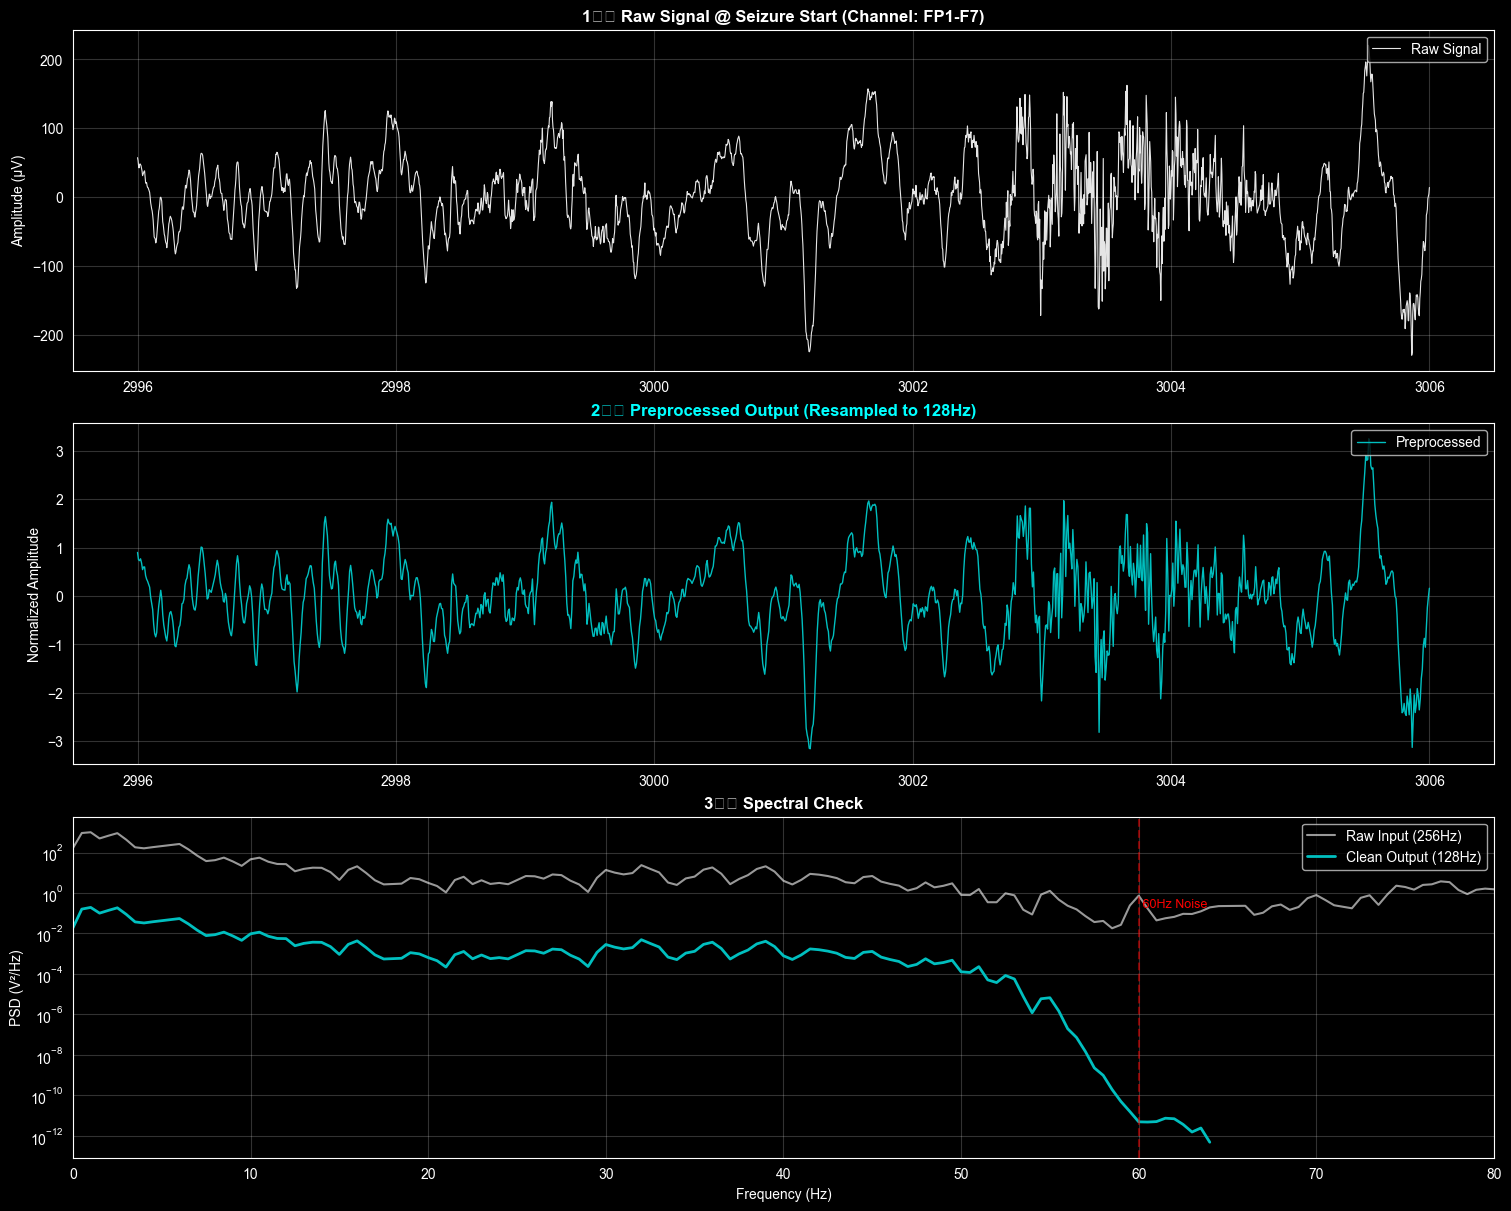

In [23]:
# --- 1. CONFIGURATION ---
seizure_start = 2996
plot_duration = 10
channel_idx = 0
buffer_sec = 5.0      # NEW: Add buffer to prevent filter edge artifacts

# Setup Paths
dataset_path = 'data-understanding/data/chb-mit'
sample_file = os.path.join(dataset_path, 'chb01', 'chb01_03.edf')

# Load Data (Replace 'deniz' with your actual loader if needed)
# signals, channel_names, fs = deniz.load_edf_file(sample_file)
# For testing, ensure 'signals' is loaded here.
# fs = 256 # Explicitly ensuring fs exists if loader is skipped

fs_raw = fs
preprocessor = EEGPreprocessor(sampling_rate=fs_raw, target_sfreq=128)
fs_clean = preprocessor.target_sfreq

# --- 2. ROBUST SLICING (With Buffer) ---
# We extract a larger chunk (buffer + window + buffer) to let the filter settle
t_start_padded = max(0, seizure_start - buffer_sec)
t_end_padded = seizure_start + plot_duration + buffer_sec

idx_start_padded = int(t_start_padded * fs_raw)
idx_end_padded = int(t_end_padded * fs_raw)

# Extract Padded Raw Data
raw_padded_chunk = signals[:, idx_start_padded:idx_end_padded]

# Preprocess the Padded Chunk
clean_padded_chunk = preprocessor.preprocess(raw_padded_chunk)

# --- 3. CROP TO DESIRED WINDOW ---
# Now we cut out exactly the 10 seconds we want to see from the middle
# Calculate indices relative to the padded chunk
rel_start_sec = seizure_start - t_start_padded
rel_end_sec = rel_start_sec + plot_duration

# Raw indices (relative to chunk)
r_start = int(rel_start_sec * fs_raw)
r_end = int(rel_end_sec * fs_raw)
raw_segment = raw_padded_chunk[channel_idx, r_start:r_end]

# Clean indices (relative to chunk, using NEW fs)
c_start = int(rel_start_sec * fs_clean)
c_end = int(rel_end_sec * fs_clean)
clean_segment = clean_padded_chunk[channel_idx, c_start:c_end]

# Time Axes
time_raw = np.linspace(seizure_start, seizure_start + plot_duration, len(raw_segment))
time_clean = np.linspace(seizure_start, seizure_start + plot_duration, len(clean_segment))

# --- 4. VISUALIZATION (Fixed Colors) ---
plt.style.use('dark_background') # Explicitly setting dark mode to match your image
fig, axes = plt.subplots(3, 1, figsize=(15, 12), constrained_layout=True)

# Plot 1: Raw Signal
# FIX: Changed 'k-' (black) to 'w-' (white) or 'cyan' to be visible
axes[0].plot(time_raw, raw_segment, 'w-', linewidth=0.8, alpha=0.9, label='Raw Signal')
axes[0].set_title(f'1️⃣ Raw Signal @ Seizure Start (Channel: {channel_names[channel_idx]})',
                  fontweight='bold', fontsize=12, color='white')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].grid(True, alpha=0.2)
axes[0].legend(loc='upper right')

# Plot 2: Preprocessed
axes[1].plot(time_clean, clean_segment, 'c-', linewidth=1, label='Preprocessed') # Cyan color
axes[1].set_title(f'2️⃣ Preprocessed Output (Resampled to {fs_clean}Hz)',
                  fontweight='bold', fontsize=12, color='cyan')
axes[1].set_ylabel('Normalized Amplitude')
axes[1].grid(True, alpha=0.2)
axes[1].legend(loc='upper right')

# Plot 3: PSD Comparison
f_raw, p_raw = welch(raw_segment, fs=fs_raw, nperseg=min(len(raw_segment), fs_raw*2))
f_clean, p_clean = welch(clean_segment, fs=fs_clean, nperseg=min(len(clean_segment), fs_clean*2))

# FIX: Changed raw color to 'white' or 'gray' so it shows up
axes[2].semilogy(f_raw, p_raw, 'w-', alpha=0.6, label=f'Raw Input ({fs_raw}Hz)')
axes[2].semilogy(f_clean, p_clean, 'c-', linewidth=2, label=f'Clean Output ({fs_clean}Hz)')

axes[2].set_title('3️⃣ Spectral Check', fontweight='bold', fontsize=12, color='white')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('PSD (V²/Hz)')
axes[2].set_xlim(0, 80)
axes[2].legend(loc='upper right')
axes[2].grid(True, which='both', alpha=0.2)

# Annotation
axes[2].axvline(x=60, color='red', linestyle='--', alpha=0.5)
axes[2].text(60, max(p_clean), ' 60Hz Noise', color='red', fontsize=9)

plt.show()

In [21]:
print(matplotlib.__version__)

3.10.8


In [24]:
import os
import numpy as np

file_path = "chb_mit_dataset_2seconds_epoch.npz"

if os.path.exists(file_path):
    # Load the compressed numpy file
    sample = np.load(file_path)
    X = sample['X']  # EEG Signal
    y = sample['y']  # Label

    print("=" * 40)
    print(f" File Analysis: {os.path.basename(file_path)}")
    print("=" * 40)

    # Display Dimensions
    print(f"🔹 Signal Shape (Channels, Time): {X.shape}")
    print(f"🔹 Class Label: {y}")

    # Display nonzero labels and unique labels
    print("=" * 40)
    print(f'label uniques', set(y))
    print(f'non zero count', np.count_nonzero(y))
    # Logic Check
    # 2 seconds * 128 Hz = 256 samples
    expected_shape = (18, 256)

    print("=" * 40)
    print(f" File Analysis: {os.path.basename(file_path)}")
    print("=" * 40)

    if X.shape == expected_shape:
        print(" Dimensions are correct (18 channels, 256 time points).")
    else:
        print(f"️ Unexpected dimensions! Expected {expected_shape}, got {X.shape}")
else:
    print(f" File not found: {file_path}")

 File Analysis: chb_mit_dataset_2seconds_epoch.npz
🔹 Signal Shape (Channels, Time): (15129, 18, 256)
🔹 Class Label: [0. 0. 0. ... 0. 0. 1.]
label uniques {np.float64(0.0), np.float64(1.0)}
non zero count 5043
 File Analysis: chb_mit_dataset_2seconds_epoch.npz
️ Unexpected dimensions! Expected (18, 256), got (15129, 18, 256)


In [25]:
print(X)

[[[-7.73561299e-02  3.35493833e-01  9.76462811e-02 ... -3.05514127e-01
    7.63996169e-02 -3.34842861e-01]
  [-5.13639227e-02  2.22923402e-02  6.05910003e-01 ...  2.82012850e-01
   -4.39392112e-04 -1.75834000e-01]
  [ 1.17062604e+00  7.60784984e-01  7.97680378e-01 ... -9.29721415e-01
   -9.00527775e-01 -3.48345578e-01]
  ...
  [ 1.66432425e-01  1.12702072e-01  5.11960268e-01 ... -4.71263528e-01
    1.12418048e-02  2.46506333e-01]
  [ 7.35597372e-01  4.93011624e-01  4.01641786e-01 ... -3.03968072e-01
   -2.65508890e-01 -2.76255012e-01]
  [ 1.47666022e-01  1.53435141e-01  1.29410401e-01 ...  7.05147237e-02
    8.23669657e-02  9.38860402e-02]]

 [[-5.79103291e-01 -7.06788003e-01 -8.10155571e-01 ... -2.22962648e-02
    4.52181883e-02 -6.10993914e-02]
  [ 1.02844691e+00  1.10029960e+00  1.21969128e+00 ...  5.15055597e-01
    6.26555383e-01  6.37583733e-01]
  [ 2.44602351e-03 -8.85107636e-01 -9.24505889e-01 ...  3.23475778e-01
    3.86661619e-01  5.01664639e-01]
  ...
  [ 2.13164231e-03 -1.2

In [26]:
print(set(y))

{np.float64(0.0), np.float64(1.0)}


In [ ]:
# # Use os.path.join to handle the folder correctly
# file_path = os.path.join("dataset_final/train/chb10", "chb10_27.npz")
#
# print(f"Loading file from: {file_path}")
#
# try:
#     # Load the .npz file
#     preprocessed_data = np.load(file_path, allow_pickle=True)
#
#     # 1. Extract the actual data array
#     print(f"Keys in file: {preprocessed_data.files}")
#     eeg_data = preprocessed_data[preprocessed_data.files[0]]
#
#     print(f"Original Shape: {eeg_data.shape}")
#     # Likely (1800, 18, 256) -> (Epochs, Channels, Time)
#
#     # 2. FIX: Convert 3D Epochs to 2D Continuous Data
#     if eeg_data.ndim == 3:
#         print(" Detected 3D Epoch data. Reshaping to 2D continuous...")
#
#         # Step A: Move Channels to the first dimension
#         # Current: (Epochs, Channels, Time) -> Target: (Channels, Epochs, Time)
#         eeg_data = np.transpose(eeg_data, (1, 0, 2))
#
#         # Step B: Flatten Epochs and Time into one continuous time dimension
#         # Shape becomes: (Channels, Epochs * Time)
#         n_channels = eeg_data.shape[0]
#         eeg_data = eeg_data.reshape(n_channels, -1)
#
#         print(f" New 2D Shape: {eeg_data.shape}")
#
#     # 3. Define Metadata manually
#     sfreq = 128.0  # Assuming 128Hz
#     ch_names = [   # Standard CHB-MIT 18 channels
#         'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
#         'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
#         'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
#         'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
#         'FZ-CZ', 'CZ-PZ'
#     ]
#
#     # Create MNE info object
#     info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
#
#     # Create RawArray object (Now receives correct 2D data)
#     raw = mne.io.RawArray(eeg_data, info)
#
#     # --- PLOTTING SECTION ---
#
#     # Reset any previous style to default (White)
#     plt.style.use('default')
#
#     # 1. Plot Raw Traces
#     fig_raw = raw.plot(
#         scalings='auto',
#         duration=10,
#         n_channels=len(ch_names),
#         show=False,
#         title="Preprocessed EEG (Reshaped from Epochs)",
#         color=dict(eeg='black'),
#         block=False
#     )
#     fig_raw.patch.set_facecolor('white')
#
#     # 2. Plot Power Spectral Density (PSD)
#     fig_psd = raw.compute_psd(fmax=50).plot(
#         average=True,
#         spatial_colors=True,
#         show=False
#     )
#     fig_psd.patch.set_facecolor('white')
#
#     # Show all plots
#     plt.show()
#
# except FileNotFoundError:
#     print(f" Error: Could not find file at '{file_path}'")
# except Exception as e:
#     print(f" An error occurred: {e}")

# Plot both PSDs per channel

In [ ]:
# # This resets matplotlib to the standard white-background scientific style
# plt.style.use('default')
#
# # Generate the plot
# fig_psd = raw.compute_psd(fmax=50).plot(
#     average=False,
#     spatial_colors=True,
#     show=False
# )
#
# # Option 2: The "Manual" Fix (If Option 1 doesn't work)
# # Explicitly paint the background white and text black
# fig_psd.patch.set_facecolor('white') # Outer background
#
# for ax in fig_psd.axes:
#     ax.set_facecolor('white')        # Inner plot background
#
#     # Set text and lines to black for visibility
#     ax.xaxis.label.set_color('black')
#     ax.yaxis.label.set_color('black')
#     ax.title.set_color('black')
#     ax.tick_params(axis='x', colors='black')
#     ax.tick_params(axis='y', colors='black')
#
#     # Make borders black
#     for spine in ax.spines.values():
#         spine.set_edgecolor('black')
#
# # Finally show the plot
# plt.show()

In [ ]:
# # Suppress warnings for cleaner output
# from scipy.signal import welch
# import warnings
# warnings.filterwarnings("ignore")
#
# # ============================================
# # 1. SETUP & LOADING
# # ============================================
# dataset_path = 'data-understanding/data/chb-mit'
# subject_folders = deniz.get_folder_names(dataset_path)
#
# FINAL_CHANNELS = [
#     'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
#     'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
#     'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
#     'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
#     'FZ-CZ', 'CZ-PZ'
# ]
#
# # Ensure we have data to load
# if not subject_folders:
#     raise FileNotFoundError(f"No subject folders found in {dataset_path}")
#
# # Get paths for the first subject
# edf_paths = deniz.get_edf_paths(dataset_path, subject_folders[0])
# file_path = edf_paths[0]
# print(f" Loading data from: {file_path}")
#
# # 1. Load using your utility
# # Note: Ensure this matches the function name in your my_utils.py
# raw = deniz.fix_eeg_channels(file_path, FINAL_CHANNELS)
#
# # 2. Extract info before processing
# original_fs = int(raw.info['sfreq'])
# print(f"   Original Sampling Rate: {original_fs} Hz")
#
# # Select a specific channel to visualize
# channel_name = FINAL_CHANNELS[0]
# channel_idx = raw.ch_names.index(channel_name)
#
# # Get 5 seconds of RAW data (converted to µV for readability)
# duration_sec = 5
# raw_samples = int(duration_sec * original_fs)
# raw_signal = raw.get_data(picks=[channel_idx], stop=raw_samples)[0] * 1e6
#
# # ============================================
# # 2. DEFINE PREPROCESSING LOGIC
# # ============================================
#
# def get_processed_segment(raw_obj, channel_idx, duration_sec):
#     # Create a copy to avoid modifying the original 'raw' object
#     raw_copy = raw_obj.copy()
#
#     # 1. Downsample
#     raw_copy = deniz.downsample(raw_copy)
#     new_fs = int(raw_copy.info['sfreq'])
#
#     # 2. Apply Filtering (Bandpass + Notch)
#     raw_copy = deniz.apply_filtering(raw_copy)
#
#     # 3. Extract Data
#     n_samples = int(duration_sec * new_fs)
#     data = raw_copy.get_data(picks=[channel_idx], stop=n_samples)[0]
#
#     return data, new_fs
#
# # Get the processed version
# clean_signal, new_fs = get_processed_segment(raw, channel_idx, duration_sec)
#
# # ============================================
# # 3. VISUALIZATION
# # ============================================
#
# print("="*60)
# print(" VISUALIZING PREPROCESSING EFFECT")
# print("="*60)
#
# # Time vectors
# time_raw = np.arange(len(raw_signal)) / original_fs
# time_clean = np.arange(len(clean_signal)) / new_fs
#
# # Apply Dark Background Style
# plt.style.use('dark_background')
#
# # Create figure
# fig, axes = plt.subplots(3, 1, figsize=(14, 12))
#
# # Plot 1: Raw Signal
# # Using 'cyan' for better visibility on black background
# axes[0].plot(time_raw, raw_signal, color='cyan', linewidth=0.8)
# axes[0].set_title(f' Raw Signal (Channel: {channel_name} @ {original_fs}Hz)', fontweight='bold')
# axes[0].set_ylabel('Amplitude (μV)')
# axes[0].grid(True, alpha=0.3)
# axes[0].set_xlim(0, duration_sec)
#
# # Plot 2: Cleaned Signal
# # Using 'lime' (bright green) for contrast
# axes[1].plot(time_clean, clean_signal, color='lime', linewidth=0.8)
# axes[1].set_title(f' Processed (Downsampled to {new_fs}Hz + Filtered)', fontweight='bold')
# axes[1].set_ylabel('Amplitude (Processed)')
# axes[1].grid(True, alpha=0.3)
# axes[1].set_xlim(0, duration_sec)
#
# # Plot 3: Power Spectrum Comparison
# freqs_raw, psd_raw = welch(raw_signal, fs=original_fs, nperseg=original_fs*2)
# freqs_clean, psd_clean = welch(clean_signal, fs=new_fs, nperseg=new_fs*2)
#
# # Normalize PSD for visual comparison
# psd_raw_norm = psd_raw / np.max(psd_raw)
# psd_clean_norm = psd_clean / np.max(psd_clean)
#
# axes[2].semilogy(freqs_raw, psd_raw_norm, color='cyan', alpha=0.5, label='Raw (Normalized PSD)', linewidth=1.5)
# axes[2].semilogy(freqs_clean, psd_clean_norm, color='lime', alpha=0.9, label='Cleaned (Normalized PSD)', linewidth=1.5)
#
# # Markers for Filter Effects
# axes[2].axvline(x=60, color='red', linestyle='--', alpha=0.8, label='60 Hz Notch')
# axes[2].axvspan(60, 128, color='white', alpha=0.1, label='High Freq Removal')
#
# axes[2].set_title('Power Spectrum (Frequency Content)', fontweight='bold')
# axes[2].set_xlabel('Frequency (Hz)')
# axes[2].set_ylabel('Normalized Power (Log Scale)')
# axes[2].set_xlim(0, 100)
# axes[2].legend(loc='upper right')
# axes[2].grid(True, alpha=0.3, which='both')
#
# plt.tight_layout()
#
# plt.savefig(output_file, dpi=150, bbox_inches='tight')
# plt.show(block=True)
#
# print("\n Preprocessing Effects Observed:")
# print(f"   ✓ Sampling Rate: {original_fs}Hz -> {new_fs}Hz")
# print("   ✓ High-frequency noise (>60Hz) reduced")
# print("   ✓ 60 Hz power line peak removed")
#
# print("\n" + "="*60)
# print(" Visualization complete!")
# print("="*60)

In [ ]:
# Final label verification
import numpy as np
path = "dataset_final/train/chb08/chb08_02_train.npz"
npz = np.load(path)
npz['X']
np.count_nonzero(npz['y'])

In [ ]:
npz['y']


In [ ]:
np.count_nonzero(npz['y'])


In [ ]:
# Load your processed file
data = np.load("dataset_final/train/chb01/chb01_03_train.npz")
X = npz['X']  # Shape: (N, 18, 256)
y = npz['y']  # Shape: (N,)

# Get indices for each class
seizure_idxs = np.where(y == 1)[0]
normal_idxs = np.where(y == 0)[0]

print(f"Total Seizures: {len(seizure_idxs)}")
print(f"Total Background: {len(normal_idxs)}")

# --- PLOT VALIDATION ---
plt.figure(figsize=(15, 6))

# Plot Background (Label 0)
plt.subplot(1, 2, 1)
if len(normal_idxs) > 0:
    idx = normal_idxs[0]
    # Plot first 3 channels
    plt.plot(X[idx, 0, :], label='Ch 1')
    plt.plot(X[idx, 1, :] + 5, label='Ch 2 (Offset)')
    plt.plot(X[idx, 2, :] + 10, label='Ch 3 (Offset)')
    plt.title(f"Label: 0 (BACKGROUND)\nLow Amplitude, Stable")
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot Seizure (Label 1)
plt.subplot(1, 2, 2)
if len(seizure_idxs) > 0:
    idx = seizure_idxs[0]
    # Plot first 3 channels
    plt.plot(X[idx, 0, :], label='Ch 1', color='red')
    plt.plot(X[idx, 1, :] + 5, label='Ch 2 (Offset)', color='red')
    plt.plot(X[idx, 2, :] + 10, label='Ch 3 (Offset)', color='red')
    plt.title(f"Label: 1 (SEIZURE)\nHigh Amplitude, Chaotic")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
data = np.load("dataset_final/train/chb03/chb03_03_train.npz")


In [ ]:
import numpy as np

# Veriyi yükle
data_npz = np.load("dataset_final/train/chb08/chb08_02_train.npz")

# Dosya içindeki dizileri kontrol et (Genelde 'data' ve 'labels' olur)
print(f"Dosya içeriği: {data_npz.files}")

signals = data_npz['X']  # Şekli genellikle (Kanallar, Zaman) veya (Zaman, Kanallar)
labels = data_npz['y'] # Nöbet anlarını belirten dizi

In [ ]:
labels

In [ ]:
np.count_nonzero(npz['y'])


In [ ]:
import numpy as np
import mne
import matplotlib
matplotlib.use('TkAgg')

# 1. Veriyi yükle
data_npz = np.load("dataset_final/train/chb03/chb03_03_train.npz")
signals = data_npz['X']   # Şekli: (54, 18, 256)
labels = data_npz['y'] # Şekli muhtemelen: (54,) veya (54, 256)

# 2. Veriyi uç uca ekleyerek yeniden şekillendir (Reshape)
# (Epochs, Channels, Times) -> (Channels, Epochs * Times)
n_epochs, n_channels, n_times = signals.shape
signals_reshaped = signals.transpose(1, 0, 2).reshape(n_channels, -1)

# 3. MNE Bilgi Nesnesini Oluştur
sfreq = 128
ch_names = [f"EEG {i}" for i in range(n_channels)]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

# 4. Raw Nesnesini Oluştur
raw = mne.io.RawArray(signals_reshaped, info)

# 5. Etiketleri (Anotasyonları) Hazırla
# Her pencerenin bir etiketi varsa, her birini n_times kadar tekrar etmeliyiz
full_labels = np.repeat(labels, n_times)

# Geçişleri bul ve anotasyon oluştur
diff = np.diff(full_labels, prepend=0)
onsets = np.where(diff > 0)[0] / sfreq
offsets = np.where(diff < 0)[0] / sfreq

# Eğer son pencere nöbetle bitiyorsa offset ekleyelim
if len(offsets) < len(onsets):
    offsets = np.append(offsets, signals_reshaped.shape[1] / sfreq)

durations = offsets - onsets
annot = mne.Annotations(onset=onsets, duration=durations, description=['Seizure']*len(onsets))
raw.set_annotations(annot)

# 6. Görselleştir
raw.plot(scalings='auto', block=True)

In [ ]:
labels

In [ ]:
np.count_nonzero(npz['y'])
